### Loading data

In [79]:
import pandas as pd

df = pd.read_csv('../Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Analysis

In [80]:
df.shape

(200, 5)

In [81]:
df.columns


Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [83]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [84]:
df['Gender'].value_counts(
)

Gender
Female    112
Male       88
Name: count, dtype: int64

In [85]:
df.drop('CustomerID',axis=1,inplace=True)

In [86]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


### Exploratory Data Analysis

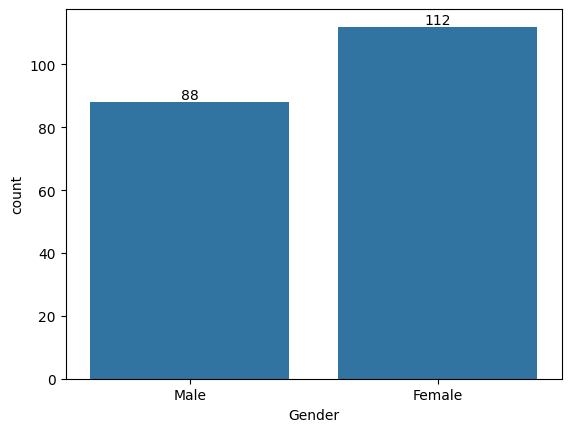

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt 
ax=sns.countplot(x=df['Gender'])
for bar in ax.containers:
    ax.bar_label(bar)


C:\Users\saipr\AppData\Local\Temp\ipykernel_20348\2219261373.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['Age'])


Text(0.5, 1.0, 'Age Distribution')

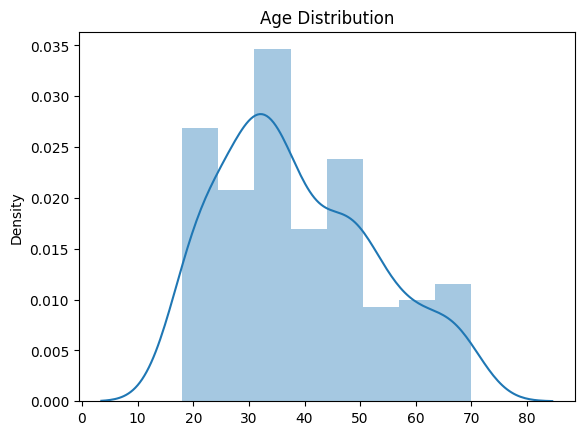

In [88]:
sns.distplot(x=df['Age'])
plt.title("Age Distribution")

<Axes: xlabel='Age', ylabel='Count'>

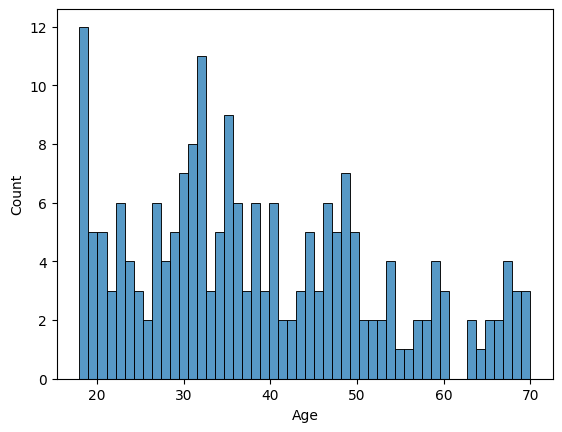

In [89]:
sns.histplot(x=df['Age'],bins=50)

<Axes: xlabel='Age'>

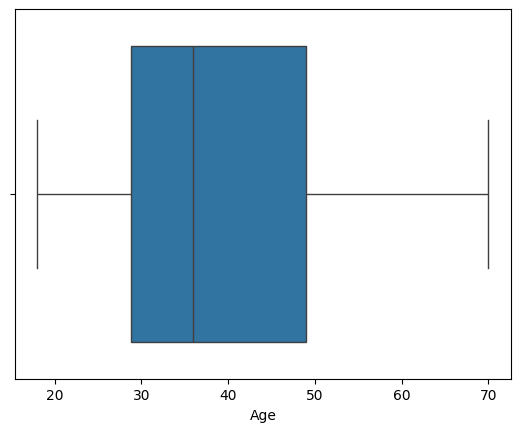

In [90]:
sns.boxplot(x=df['Age'])

C:\Users\saipr\AppData\Local\Temp\ipykernel_20348\1699561273.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['Annual Income (k$)'])


<Axes: ylabel='Density'>

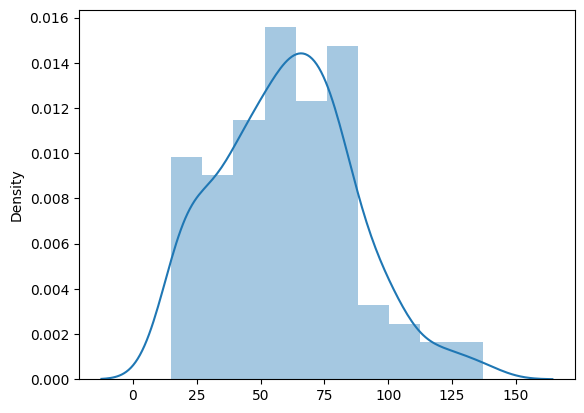

In [91]:
sns.distplot(x=df['Annual Income (k$)'])

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

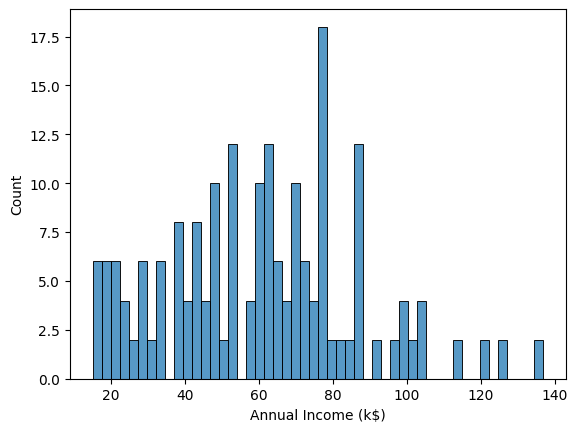

In [92]:
sns.histplot(x=df['Annual Income (k$)'],bins=50)

<Axes: xlabel='Annual Income (k$)'>

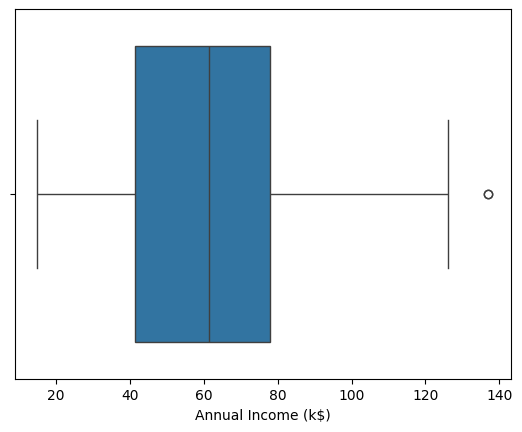

In [93]:
sns.boxplot(x=df['Annual Income (k$)'])

C:\Users\saipr\AppData\Local\Temp\ipykernel_20348\1236899733.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['Spending Score (1-100)'])


<Axes: ylabel='Density'>

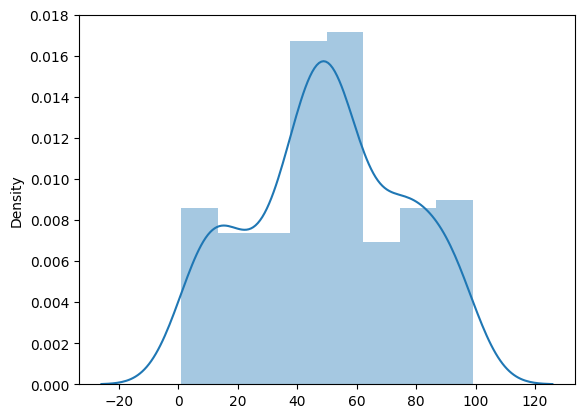

In [94]:
sns.distplot(x=df['Spending Score (1-100)'])

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

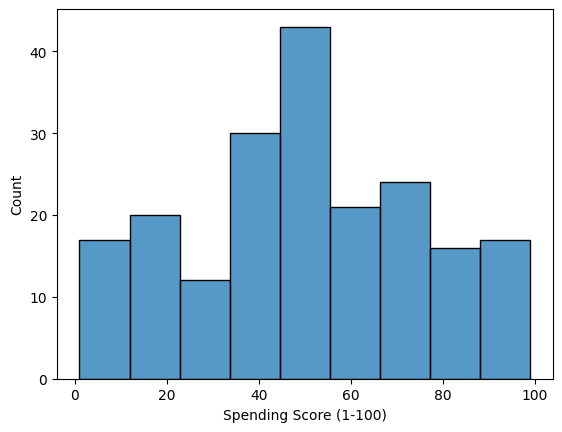

In [95]:
sns.histplot(x=df['Spending Score (1-100)'])

<Axes: xlabel='Spending Score (1-100)'>

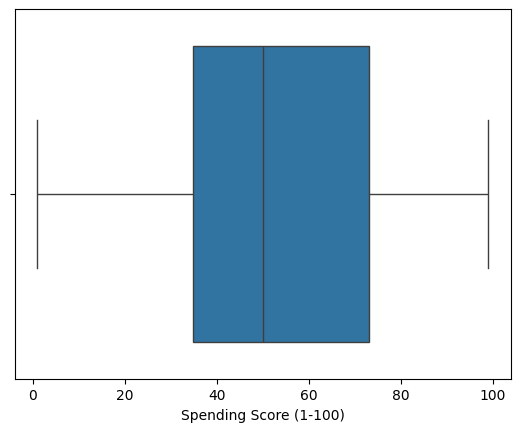

In [96]:
sns.boxplot(x=df['Spending Score (1-100)'])

In [97]:
df['Gender']=df['Gender'].map({'Male':1,'Female':0})

In [98]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


Text(0, 0.5, 'WCSS (Inertia)')

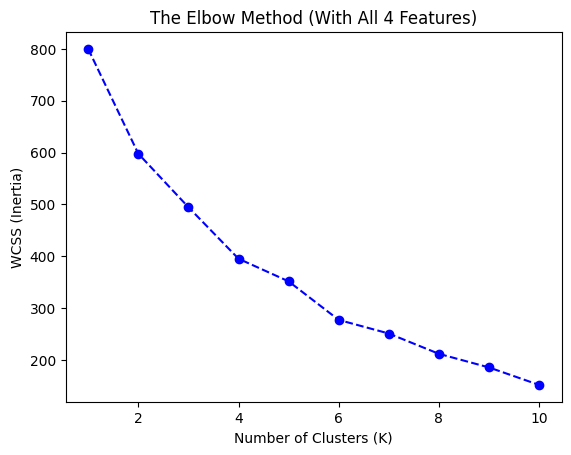

In [99]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Select all 4 columns (Gender, Age, Annual Income, Spending Score)
X = df.iloc[:, [0, 1, 2, 3]].values

# 2. Scale the features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Run the Elbow Method with the newly scaled 4D data
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 4. Plot the updated Elbow Curve
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method (With All 4 Features)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')

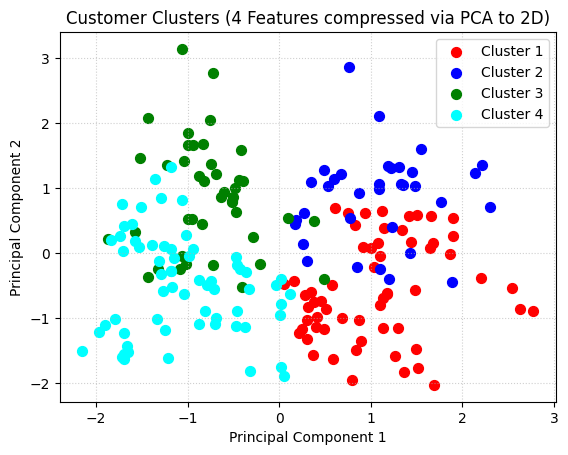

In [ ]:
from sklearn.decomposition import PCA

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange']
for i in range(optimal_k):
    plt.scatter(X_pca[y_kmeans == i, 0], X_pca[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.title('Customer Clusters (4 Features compressed via PCA to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

In [ ]:
import numpy as np

new_customer = np.array([[1, 28, 75, 82]])

new_customer_scaled = scaler.transform(new_customer)

predicted_cluster = kmeans.predict(new_customer_scaled)

print(f"The new customer belongs to: Cluster {predicted_cluster[0] + 1}")

The new customer belongs to: Cluster 3


In [103]:
kmeans.n_clusters

4

In [104]:
kmeans.cluster_centers_

array([[-0.01343038,  1.13750203, -0.5213944 , -0.39856802],
       [ 0.29862851,  0.17329545,  1.06645385, -1.2980103 ],
       [ 1.12815215, -0.72911539,  0.01315937,  0.77791013],
       [-0.88640526, -0.67998938, -0.08638219,  0.55272197]])

### Pipeline formation

In [105]:
import joblib
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, [0, 1, 2, 3]].values

pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "kmeans",
            KMeans(n_clusters=4, init="k-means++", random_state=42),
        ),
    ]
)

pipeline.fit(X)

joblib.dump(pipeline, "customer_kmeans_pipeline.pkl")
print("Pipeline saved successfully!")

Pipeline saved successfully!


In [106]:
import joblib
import numpy as np

loaded_pipeline = joblib.load("customer_kmeans_pipeline.pkl")

new_customer = np.array([[0, 32, 126, 74]])

predicted_cluster = loaded_pipeline.predict(new_customer)

print(f"The new customer belongs to: Cluster {predicted_cluster[0] + 1}")

The new customer belongs to: Cluster 4


In [ ]:
import pandas as pd

scaled_centroids = pipeline.named_steps["kmeans"].cluster_centers_

scaler_step = pipeline.named_steps["scaler"]
original_centroids = scaler_step.inverse_transform(scaled_centroids)

feature_names = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
centroids_df = pd.DataFrame(original_centroids, columns=feature_names)

centroids_df.index = [f"Cluster {i+1}" for i in range(len(centroids_df))]

print("--- Final Optimal Centroids (Original Units) ---")
centroids_df

--- Final Optimal Centroids (Original Units) ---


,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster 1,4.333333e-01,54.700000,46.900000,39.933333
Cluster 2,5.882353e-01,41.264706,88.500000,16.764706
Cluster 3,1.000000e+00,28.690476,60.904762,70.238095
Cluster 4,-4.440892e-16,29.375000,58.296875,64.437500
